In [ ]:
import os
from typing import Annotated, TypedDict, List, Dict, Any, Union, Optional

from dotenv import load_dotenv

load_dotenv()


from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool

from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command  
from langgraph.checkpoint.memory import MemorySaver  

# 4. 파이썬 실행 도구 (실무에서 권장되는 유틸리티)
from langchain_experimental.utilities import PythonREPL

from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df["target"] = iris.target

In [ ]:
class MainState(TypedDict):
    data: str
    code: str
    file_path: str
    user_choice: str
    feed_back: str
    insight_analysis: dict


class AnalysisState(TypedDict):
    user_choice: str
    prepared_data: str
    code: str
    result_summary: str
    result_img_path: str
    feed_back: str
    now_log: str
    make_insight: int
    roop_back: int

In [ ]:
# sub
repl = PythonREPL()


def make_analysis_code(state: AnalysisState):
    ## 데이터 코드 생성
    file_path = state["prepared_data"]
    df = pd.read_csv(file_path)
    Preprocessing = state["code"]
    # df와 preprocessing 코드 보고 분석코드 생성

    make_analysis_code = ""
    repl.globals["df"] = df
    all_code = Preprocessing + "\n" + make_analysis_code
    return {"code": all_code}


def run_analysis_code(state: AnalysisState):
    make_code = state["code"]
    result_summary = "좋은 경험이다"
    num = state["make_insight"]
    roop = str(state.get("roop_back", 0))
    img_path = f"insght_{num}_{roop}.png"
    img_code = f"plt.savefig('{img_path}', dpi=300, bbox_inches='tight') \nplt.show() "
    make_code += "\n" + img_code
    repl_result = repl.run(make_code)
    if repl_result:
        print(f"--- REPL 실행 로그 ---\n{repl_result}")
    return {"result_summary": result_summary, "result_img_path": img_path}


def route_wait_node(state: AnalysisState):
    pass


def router_next_step(state: AnalysisState):
    choice = state["user_choice"]
    if choice == "수정":
        return "Back"
    elif choice == "완료" or choice == "추가":
        return "END"
    else:
        pass


workflow = StateGraph(AnalysisState)
workflow.add_node("MakeAnalysisCode", make_analysis_code)
workflow.add_node("RunAnalysisCode", run_analysis_code)
workflow.add_node("WaitUserDecision", route_wait_node)
workflow.add_edge(START, "MakeAnalysisCode")
workflow.add_edge("MakeAnalysisCode", "RunAnalysisCode")
workflow.add_edge("RunAnalysisCode", "WaitUserDecision")
workflow.add_conditional_edges(
    "WaitUserDecision", router_next_step, {"Back": "MakeAnalysisCode", "END": END}
)
memory = MemorySaver()
sub_app = workflow.compile(checkpointer=memory, interrupt_before=["WaitUserDecision"])

In [ ]:
import pandas as pd


def get_df_summary(df: pd.DataFrame):
    """
    LLM에게 전달할 데이터프레임의 요약 정보를 문자열로 반환합니다.
    """
    summary = []
    summary.append(f"- 데이터 형태 (Shape): {df.shape[0]}행, {df.shape[1]}열")

    # 1. 컬럼명과 데이터 타입
    summary.append("\n- 컬럼 정보 및 타입:")
    summary.append(df.dtypes.to_string())

    # 2. 결측치 정보
    null_info = df.isnull().sum()
    if null_info.sum() > 0:
        summary.append("\n- 결측치 수:")
        summary.append(null_info[null_info > 0].to_string())
    else:
        summary.append("\n- 결측치 없음")

    # 3. 범주형 데이터의 고유값(Unique) 개수
    # 고유값이 너무 많지 않은(예: 20개 이하) 컬럼들만 골라 정보를 줍니다.
    summary.append("\n- 주요 범주형 데이터 정보:")
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count <= 20:
            summary.append(
                f"  * {col}: {unique_count}개의 고유값 ({df[col].unique()[:5]}...)"
            )
        else:
            summary.append(f"  * {col}: {unique_count}개의 고유값")

    # 4. 수치형 데이터 통계 요약
    summary.append("\n- 수치 데이터 요약 (describe):")
    summary.append(df.describe().loc[["mean", "min", "max"]].to_string())

    # 5. 실제 데이터 샘플 (Top 3)
    summary.append("\n- 데이터 샘플 (Top 3):")
    summary.append(df.head(3).to_string())

    return "\n".join(summary)

In [77]:
get_df_summary(iris_df)

'- 데이터 형태 (Shape): 150행, 5열\n\n- 컬럼 정보 및 타입:\nsepal length (cm)    float64\nsepal width (cm)     float64\npetal length (cm)    float64\npetal width (cm)     float64\ntarget                 int64\n\n- 결측치 없음\n\n- 주요 범주형 데이터 정보:\n\n- 수치 데이터 요약 (describe):\n      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target\nmean           5.843333          3.057333              3.758          1.199333     1.0\nmin            4.300000          2.000000              1.000          0.100000     0.0\nmax            7.900000          4.400000              6.900          2.500000     2.0\n\n- 데이터 샘플 (Top 3):\n   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target\n0                5.1               3.5                1.4               0.2       0\n1                4.9               3.0                1.4               0.2       0\n2                4.7               3.2                1.3               0.2       0'

In [ ]:
# Main
repl = PythonREPL()


def create_main_graph(state: MainState):
    return {"data": "iris_data.csv"}


def run_A_agent(state: MainState):
    feedback = state.get("user_choice", "")
    if feedback == "":
        code = """import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리 및 데이터 정리
df.columns = [col.replace(' (cm)', '').replace(' ', '_') for col in df.columns]

# 2. Seaborn 스타일 설정
sns.set_theme(style="whitegrid", palette="muted")

# 3. 시각화 (종별 분포 및 상관관계)
plt.figure(figsize=(10, 8))
g = sns.pairplot(df, hue="target" if "target" in df.columns else None, markers=["o", "s", "D"])
g.fig.suptitle("Iris Data Analysis", y=1.02)

# 4. 이미지 저장 (변수 save_path는 REPL에서 주입함)
# 여기서 바로 저장하지 않고 sub-app의 run_analysis_code가 save_path를 붙여줄 것입니다.
print("--- 시각화 코드 준비 완료 ---")
"""
    else:
        code = """print("Hello Fucking World")"""
        repl_result = repl.run(code)
        if repl_result:
            print(f"--- REPL 실행 로그 ---\n{repl_result}")

    return {"code": code}


def run_B_agent(state: MainState):
    input = {
        "code": state["code"],
        "prepared_data": state["data"],
        "make_insight": str(len(state.get("insight_analysis", []))),
    }
    child_result = sub_app.invoke(input)
    state["feed_back"] = child_result.get("feed_back", "")
    state["user_choice"] = child_result.get("user_choice", "")
    state["insight_analysis"] = state.get("insight_analysis", {})
    state["insight_analysis"][str(len(state["insight_analysis"]))] = {
        "result_summary": child_result.get("result_summary", ""),
        "result_img_path": child_result.get("result_img_path", ""),
    }
    return state


def route_subagent(state: MainState):
    if state["user_choice"] == "완료":
        return "END"
    elif state["user_choice"] == "추가":
        return "A"
    else:
        return "END"


workflow_main = StateGraph(MainState)
workflow_main.add_node("CreateMainGraph", create_main_graph)
workflow_main.add_node("RunAAgent", run_A_agent)
workflow_main.add_node("RunBAgent", run_B_agent)
workflow_main.add_edge(START, "CreateMainGraph")
workflow_main.add_edge("CreateMainGraph", "RunAAgent")
workflow_main.add_edge("RunAAgent", "RunBAgent")
workflow_main.add_conditional_edges(
    "RunBAgent", route_subagent, {"A": "RunAAgent", "END": END}
)
memory = MemorySaver()
main_app = workflow_main.compile(checkpointer=memory)

In [ ]:
code = """import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리 및 데이터 정리
df.columns = [col.replace(' (cm)', '').replace(' ', '_') for col in df.columns]

# 2. Seaborn 스타일 설정
sns.set_theme(style="whitegrid", palette="muted")

# 3. 시각화 (종별 분포 및 상관관계)
plt.figure(figsize=(10, 8))
g = sns.pairplot(df, hue="target" if "target" in df.columns else None, markers=["o", "s", "D"])
g.fig.suptitle("Iris Data Analysis", y=1.02)

# 4. 이미지 저장 (변수 save_path는 REPL에서 주입함)
# 여기서 바로 저장하지 않고 sub-app의 run_analysis_code가 save_path를 붙여줄 것입니다.
print("--- 시각화 코드 준비 완료 ---")
"""
path = "iris_data.csv"
num = "0"

In [ ]:
class AgentWorkflowCallback(BaseCallbackHandler):
    def on_chain_start(self, serialized, inputs, **kwargs):
        name = (serialized or {}).get("name") or kwargs.get("name")
        print(f"DEBUG: 진입 시도 중인 노드 이름 -> {name}")

    def on_chain_end(self, outputs, **kwargs):
        pass

DEBUG: 진입 시도 중인 노드 이름 -> LangGraph
DEBUG: 진입 시도 중인 노드 이름 -> CreateMainGraph
DEBUG: 진입 시도 중인 노드 이름 -> RunAAgent
📡 프론트로 전송할 코드: import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리 및 데이터 정리
df.columns = [col.replace(' (cm)', '').replace(' ', '_') for col in df.columns]

# 2. Seaborn 스타일 설정
sns.set_theme(style="whitegrid", palette="muted")

# 3. 시각화 (종별 분포 및 상관관계)
plt.figure(figsize=(10, 8))
g = sns.pairplot(df, hue="target" if "target" in df.columns else None, markers=["o", "s", "D"])
g.fig.suptitle("Iris Data Analysis", y=1.02)

# 4. 이미지 저장 (변수 save_path는 REPL에서 주입함)
# 여기서 바로 저장하지 않고 sub-app의 run_analysis_code가 save_path를 붙여줄 것입니다.
print("--- 시각화 코드 준비 완료 ---")

DEBUG: 진입 시도 중인 노드 이름 -> RunBAgent
DEBUG: 진입 시도 중인 노드 이름 -> LangGraph
DEBUG: 진입 시도 중인 노드 이름 -> MakeAnalysisCode
📡 프론트로 전송할 코드: import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리 및 데이터 정리
df.columns = [col.replace(' (cm)', '').replace(' ', '_') for col in df.columns]

<Figure size 1000x800 with 0 Axes>

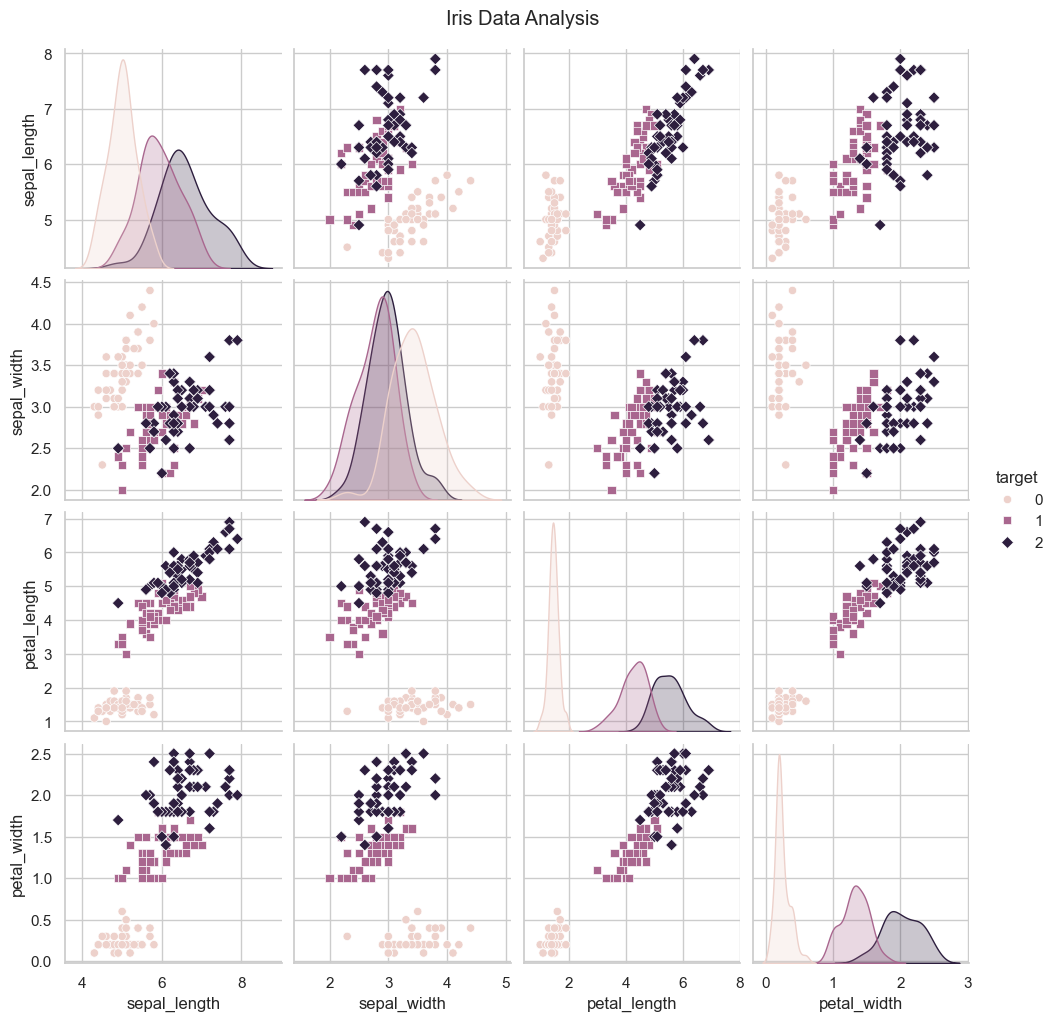

--- REPL 실행 로그 ---
--- 시각화 코드 준비 완료 ---

📡 프론트로 전송할 코드: import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리 및 데이터 정리
df.columns = [col.replace(' (cm)', '').replace(' ', '_') for col in df.columns]

# 2. Seaborn 스타일 설정
sns.set_theme(style="whitegrid", palette="muted")

# 3. 시각화 (종별 분포 및 상관관계)
plt.figure(figsize=(10, 8))
g = sns.pairplot(df, hue="target" if "target" in df.columns else None, markers=["o", "s", "D"])
g.fig.suptitle("Iris Data Analysis", y=1.02)

# 4. 이미지 저장 (변수 save_path는 REPL에서 주입함)
# 여기서 바로 저장하지 않고 sub-app의 run_analysis_code가 save_path를 붙여줄 것입니다.
print("--- 시각화 코드 준비 완료 ---")

다음 실행할 노드: ('RunBAgent',)
DEBUG: 진입 시도 중인 노드 이름 -> LangGraphUpdateState
DEBUG: 진입 시도 중인 노드 이름 -> route_subagent
DEBUG: 진입 시도 중인 노드 이름 -> LangGraph
📡 프론트로 전송할 코드: import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리 및 데이터 정리
df.columns = [col.replace(' (cm)', '').replace(' ', '_') for col in df.columns]

# 2. Seaborn 스타일 설정
sns.set_theme

In [ ]:
agent_callback = AgentWorkflowCallback()
config = {
    "configurable": {"thread_id": "test_thread_5"},
    "callbacks": [agent_callback], 
}


# 메인 앱 실행 시
for event in main_app.stream({}, config=config):
    pass

state = main_app.get_state(config)  
print(f"다음 실행할 노드: {state.next}")
main_app.update_state(config, {"user_choice": "완료"}, as_node="RunBAgent")

for event in main_app.stream(None, config=config):
    pass

{'__interrupt__': ()}
